<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-anabeatrizdscotrim/blob/main/DataSet_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando Bibliotecas


---


*   numpy e pandas: Manipulação de dados
*   matplotlib e seaborn: Visualizações
*   scikit-learn: Algoritmos de Machine Learning

---

### **scikit-learn:**
* **train_test_split:** É a ferramenta que separa seus dados. Ela "esconde" uma parte dos pinguins para testar o modelo depois, garantindo que ele não apenas decorou as respostas.

* **KNeighborsClassifier (KNN):** É o algoritmo que classifica por "vizinhança". Se um pinguim se parece com outros 5 da espécie Adelie, ele será classificado como Adelie.

* **DecisionTreeClassifier (Árvore de Decisão):** É o algoritmo que cria regras lógicas (se bico > X, então...). O plot_tree serve para desenhar essa árvore e a gente conseguir ver essas regras.

### **Métricas (Para saber se o modelo é bom)**

* **accuracy_score:** É a porcentagem total de acertos.

* **confusion_matrix e ConfusionMatrixDisplay:** Mostra exatamente onde o modelo errou (ex: confundiu um pinguim Gentoo com um Adelie).

* **classification_report:** Um resumo que mostra outros detalhes técnicos (como precisão e sensibilidade) para cada espécie.


In [ ]:
# Manipulação de Dados
import numpy as np
import pandas as pd

# Visualizações
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Separação treino/teste
from sklearn.model_selection import train_test_split

# Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Etapa 1 - Carregamento dos Dados
importando o dataset


---

Foi utilizado o método concat() do pandas para unir os dados dos vinhos tintos e brancos em uma única tabela, facilitando a análise e o treinamento do modelo.


In [ ]:
vinhos_tintos = pd.read_csv('/content/sample_data/winequality-red.csv', sep=';')
vinhos_tintos['categoria'] = 'tinto'

vinhos_brancos = pd.read_csv('/content/sample_data/winequality-white.csv', sep=';')
vinhos_brancos['categoria'] = 'branco'

base_vinhos = pd.concat([vinhos_tintos, vinhos_brancos], ignore_index=True)

base_vinhos

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,categoria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,tinto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,branco
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,branco
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,branco
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,branco


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Etapa 2 - Exploração dos Dados


---

O método info() foi utilizado para visualizar a estrutura geral do DataFrame, permitindo identificar:

* quantidade de registros;
* nomes das colunas;
* tipos de dados;
* presença de valores nulos.

Já o método head() exibe as primeiras linhas da tabela, facilitando a visualização inicial dos dados carregados.

---

O dataset possui 6497 amostras de vinhos e o dataset não possui dados faltantes

In [ ]:
base_vinhos.info()

print('=' * 100)

base_vinhos.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  categoria             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,categoria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


# Estatísticas Descritivas

O método `describe()` foi utilizado para gerar um resumo estatístico das variáveis numéricas do dataset.  
Com ele é possível visualizar informações importantes como:

- quantidade de registros  
- média dos valores  
- desvio padrão  
- valores mínimos e máximos  
- distribuição dos quartis  

Já o comando `round(2)` foi aplicado para limitar os resultados a duas casas decimais, facilitando a leitura das informações.

## Principais indicadores apresentados:

- **count:** quantidade de valores preenchidos em cada coluna  
- **mean:** média aritmética dos dados  
- **std:** medida de dispersão dos valores em relação à média  
- **min e max:** menores e maiores valores encontrados  
- **25%, 50% e 75%:** quartis utilizados para entender a distribuição dos dados  

A análise mostrou que todas as colunas possuem 6497 registros válidos, confirmando que não existem dados ausentes no conjunto analisado.

In [ ]:
base_vinhos.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.06,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


# Etapa 3 - Visualização Grafica dos Dados

## Descobertas Baseadas em Evidências (Análise Química dos Vinhos)

Abaixo estão apresentadas três descobertas fundamentadas nas características químicas do dataset unificado de vinhos, acompanhadas de suas respectivas justificativas estatísticas e interpretações técnicas.

---

### Descoberta 1: O Impacto Negativo da Acidez Volátil na Qualidade

* **Afirmação:** Vinhos com menor acidez volátil (`volatile acidity`) tendem a receber notas de qualidade mais altas da banca de especialistas.
* **Evidência:** Existe uma correlação negativa expressiva de aproximadamente $-0.27$ entre a acidez volátil e a nota final do vinho. Ao agruparmos as médias dessa variável por nota de qualidade (`quality`), observa-se um declínio rigorosamente constante:
    * **Vinhos de qualidade baixa (Nota 3):** média de $0.517\ g/dm^3$ de acidez volátil.
    * **Vinhos de qualidade intermediária (Nota 6):** média de $0.314\ g/dm^3$ de acidez volátil.
    * **Vinhos de qualidade excelente (Nota 9):** média de apenas $0.298\ g/dm^3$ de acidez volátil.
    *(Sustentado estatisticamente pelo Gráfico de Barras gerado abaixo e pela tabela de médias aglutinadas).*
* A acidez volátil mede a quantidade de ácidos acéticos presentes no vinho (o principal componente do vinagre). Níveis elevados dessa substância geram um odor forte, azedo e acético que mascara as propriedades aromáticas nobres e os sabores desejáveis da bebida. Por esse motivo, vinhos com controle rigoroso e baixos índices de acidez volátil recebem as melhores pontuações na avaliação sensorial.

---

### Descoberta 2: A Necessidade de Conservantes em Brancos vs. Tintos

* **Afirmação:** Vinhos brancos demandam e possuem uma concentração significativamente maior de Dióxido de Enxofre Total (`total sulfur dioxide`) em comparação aos vinhos tintos.
* **Evidência:** A análise descritiva aponta que a média de dióxido de enxofre total para os vinhos brancos é de $138.36\ mg/dm^3$, enquanto para os vinhos tintos é de apenas $46.47\ mg/dm^3$. Trata-se de uma diferença drástica onde o vinho branco carrega quase **3 vezes mais** conservantes que o tinto.
    *(Sustentado estatisticamente pelo Boxplot comparativo de categorias gerado abaixo).*
* O dióxido de enxofre ($SO_2$) é o conservante mais crucial da vinificação, atuando como antioxidante e antimicrobiano. Os vinhos tintos passam pelo processo de maceração com as cascas das uvas, absorvendo uma grande carga de compostos fenólicos (como os taninos), que atuam como excelentes protetores e antioxidantes naturais. Como os vinhos brancos carecem dessa barreira de taninos protetores, eles oxidam e deterioram com extrema facilidade, exigindo uma adição química de $SO_2$ muito maior para manter o frescor e a estabilidade comercial.

---

### Descoberta 3: A Relação entre Salinidade (Cloretos) e a Percepção de Qualidade

* **Afirmação:** Vinhos com menor concentração de cloretos (`chlorides`) são associados a patamares de qualidade superiores.
* **Evidência:** Há uma correlação negativa de $-0.20$ indicando que quanto mais cloretos no vinho, pior tende a ser sua nota. O comportamento das médias decresce de forma linear conforme a qualidade aumenta:
    * **Nota 3 (Qualidade Baixa):** média de $0.077\ g/dm^3$ de cloretos.
    * **Nota 6 (Qualidade Média):** média de $0.054\ g/dm^3$ de cloretos.
    * **Nota 9 (Qualidade Excelente):** média de apenas $0.027\ g/dm^3$ de cloretos.
    *(Sustentado estatisticamente pelo Gráfico Decrescente de Cloretos por Nota).*
* Os cloretos expressam fundamentalmente a quantidade de sais minerais (salinidade) diluídos na bebida. Esse acúmulo geralmente ocorre por conta de solos naturalmente salinos ou irrigação com água salobra. No paladar, o excesso de cloretos confere uma sensação salgada, pesada, metálica e desagradável, que arruína a harmonia do vinho. Consequentemente, vinhos mais limpos, elegantes e de sabor equilibrado apresentam baixíssimos índices de cloreto.

--- EVIDÊNCIAS EM TABELAS ---

Média de Acidez Volátil por Nota de Qualidade:
quality
3    0.517
4    0.458
5    0.390
6    0.314
7    0.289
8    0.291
9    0.298
Name: volatile acidity, dtype: float64

Média de Dióxido de Enxofre Total por Tipo de Vinho:
categoria
branco    138.36
tinto      46.47
Name: total sulfur dioxide, dtype: float64

Média de Cloretos por Nota de Qualidade:
quality
3    0.077
4    0.060
5    0.065
6    0.054
7    0.045
8    0.041
9    0.027
Name: chlorides, dtype: float64

--- GERANDO OS GRÁFICOS ---


/tmp/ipykernel_2158/2155164348.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


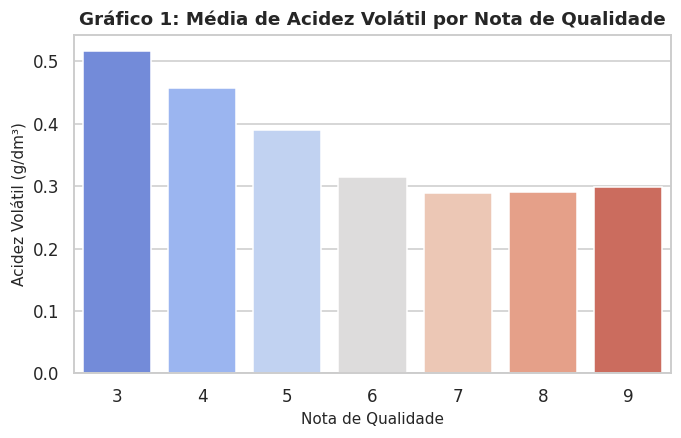

/tmp/ipykernel_2158/2155164348.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


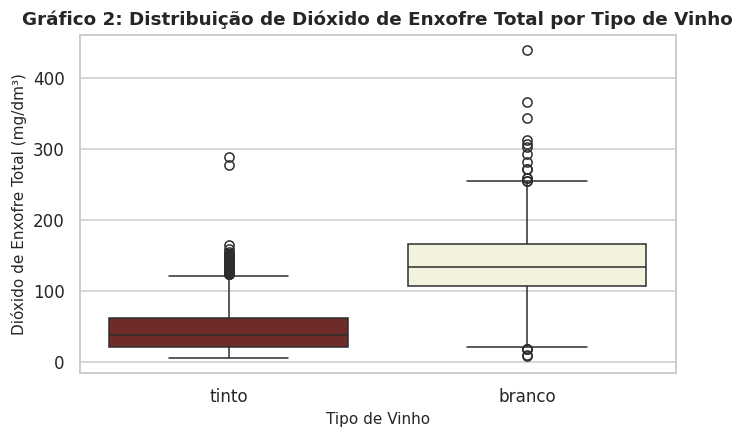

/tmp/ipykernel_2158/2155164348.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


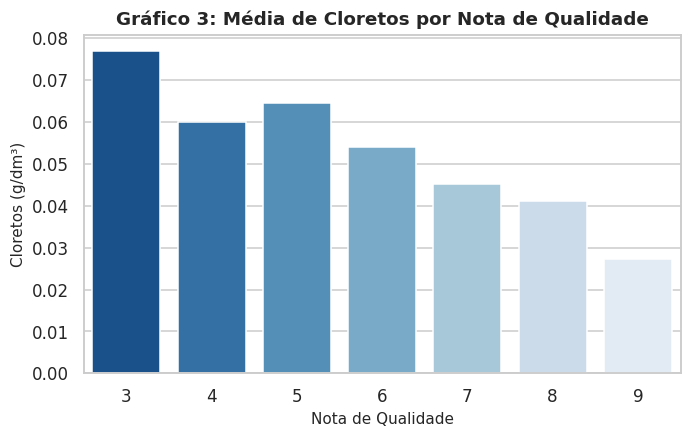

In [ ]:
sns.set_theme(style="whitegrid")

print("--- EVIDÊNCIAS EM TABELAS ---")

print("\nMédia de Acidez Volátil por Nota de Qualidade:")
print(base_vinhos.groupby('quality')['volatile acidity'].mean().round(3))

print("\nMédia de Dióxido de Enxofre Total por Tipo de Vinho:")
print(base_vinhos.groupby('categoria')['total sulfur dioxide'].mean().round(2))

print("\nMédia de Cloretos por Nota de Qualidade:")
print(base_vinhos.groupby('quality')['chlorides'].mean().round(3))


print("\n" + "="*50 + "\n--- GERANDO OS GRÁFICOS ---")

plt.figure(figsize=(7, 4))
sns.barplot(
    x='quality',
    y='volatile acidity',
    data=base_vinhos,
    palette='coolwarm',
    errorbar=None
)
plt.title('Gráfico 1: Média de Acidez Volátil por Nota de Qualidade', fontsize=12, fontweight='bold')
plt.xlabel('Nota de Qualidade', fontsize=10)
plt.ylabel('Acidez Volátil (g/dm³)', fontsize=10)
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(
    x='categoria',
    y='total sulfur dioxide',
    data=base_vinhos,
    palette=['#7B1E1E', '#F5F5DC']
)
plt.title('Gráfico 2: Distribuição de Dióxido de Enxofre Total por Tipo de Vinho', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Vinho', fontsize=10)
plt.ylabel('Dióxido de Enxofre Total (mg/dm³)', fontsize=10)
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(
    x='quality',
    y='chlorides',
    data=base_vinhos,
    palette='Blues_r',
    errorbar=None
)
plt.title('Gráfico 3: Média de Cloretos por Nota de Qualidade', fontsize=12, fontweight='bold')
plt.xlabel('Nota de Qualidade', fontsize=10)
plt.ylabel('Cloretos (g/dm³)', fontsize=10)
plt.show()